In [1]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load data
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

# Convert dates to proper format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract year and month for time analysis
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Year'] = df['Order Date'].dt.to_period('M')

# Check missing values
print("Missing values:")
print(df.isnull().sum())
print("\nData cleaned successfully!")
print(f"Total Orders: {len(df):,}")
print(f"Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Month_Year       0
dtype: int64

Data cleaned successfully!
Total Orders: 9,994
Total Revenue: $2,297,200.86
Total Profit: $286,397.02


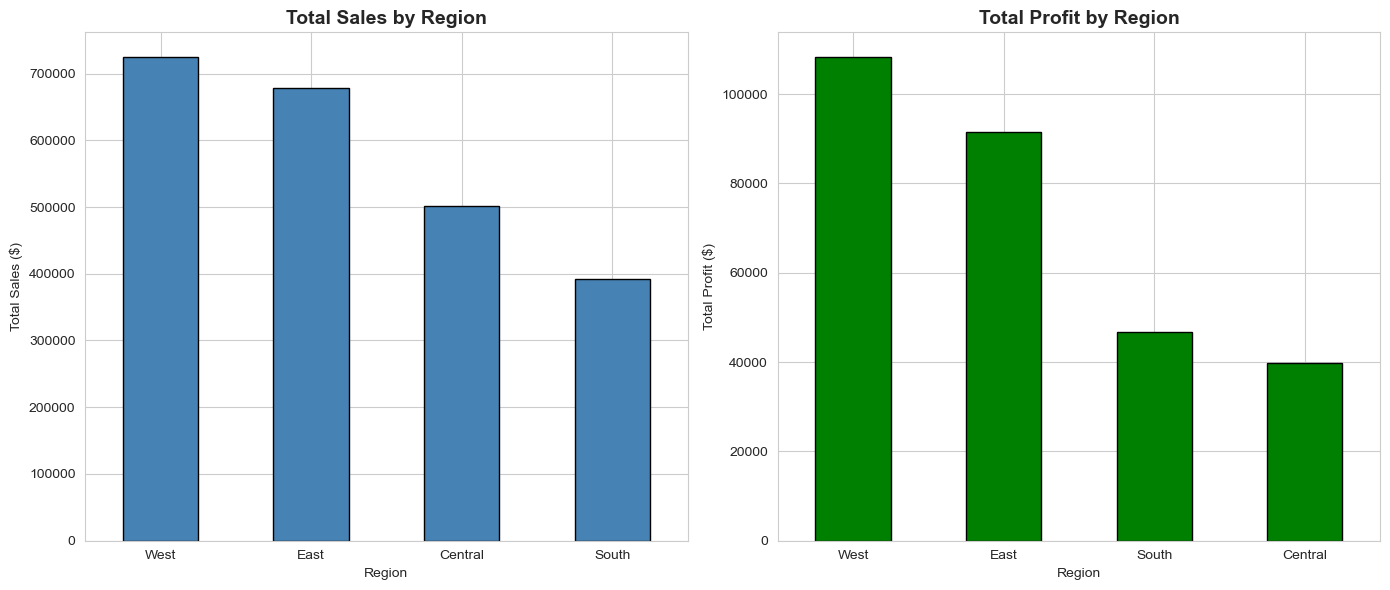


Highest Sales Region: West ($725,457.82)
Highest Profit Region: West ($108,418.45)


In [3]:
# Which region generates highest revenue?
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sales by Region
region_sales.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total Sales by Region', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=0)

# Profit by Region
region_profit.plot(kind='bar', ax=axes[1], color='green', edgecolor='black')
axes[1].set_title('Total Profit by Region', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Profit ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('region_analysis.png', dpi=150)
plt.show()

print(f"\nHighest Sales Region: {region_sales.index[0]} (${region_sales.values[0]:,.2f})")
print(f"Highest Profit Region: {region_profit.index[0]} (${region_profit.values[0]:,.2f})")

Category Performance:
          Category  Total_Sales  Total_Profit  Profit_Margin_%
0        Furniture  741999.7953    18451.2728             2.49
1  Office Supplies  719047.0320   122490.8008            17.04
2       Technology  836154.0330   145454.9481            17.40


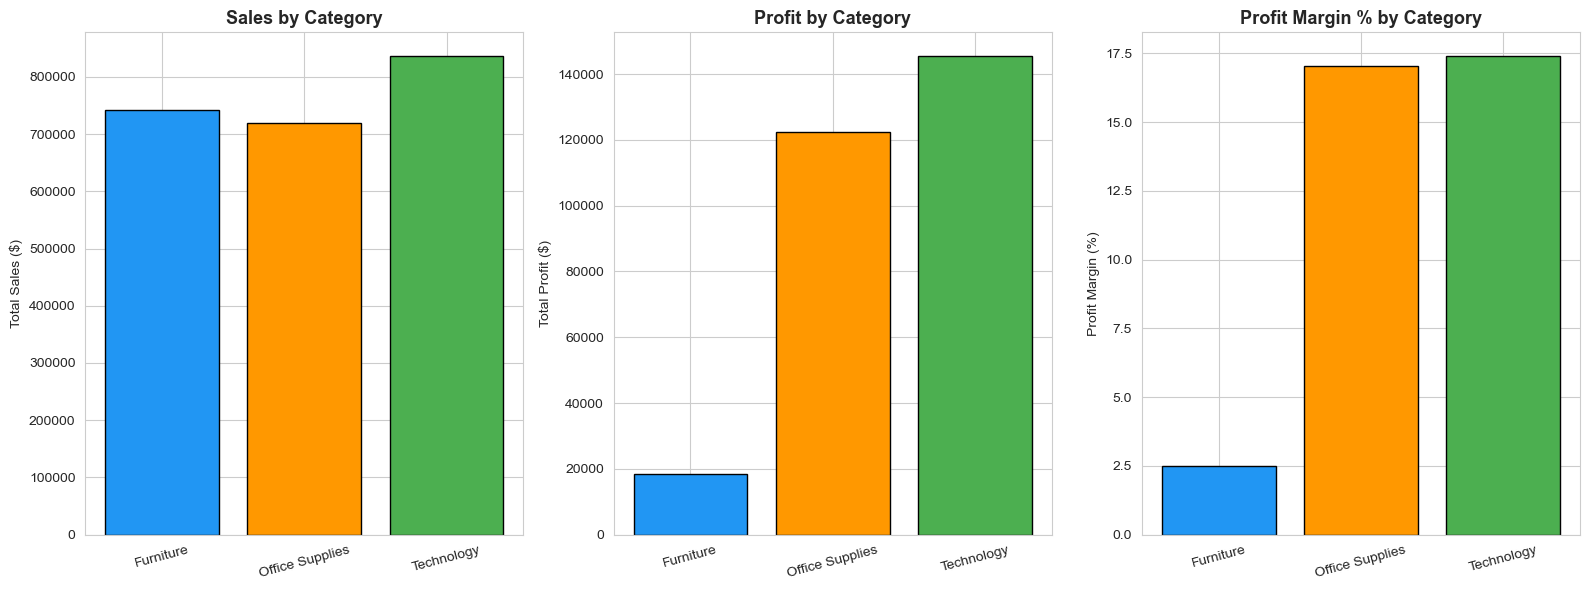

In [4]:
# Which category has best/worst profit margin?
category_stats = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

category_stats['Profit_Margin_%'] = round(
    (category_stats['Total_Profit'] / category_stats['Total_Sales']) * 100, 2
)

print("Category Performance:")
print(category_stats)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Sales by Category
axes[0].bar(category_stats['Category'], category_stats['Total_Sales'],
            color=['#2196F3','#FF9800','#4CAF50'], edgecolor='black')
axes[0].set_title('Sales by Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=15)

# Profit by Category
axes[1].bar(category_stats['Category'], category_stats['Total_Profit'],
            color=['#2196F3','#FF9800','#4CAF50'], edgecolor='black')
axes[1].set_title('Profit by Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')
axes[1].tick_params(axis='x', rotation=15)

# Profit Margin by Category
axes[2].bar(category_stats['Category'], category_stats['Profit_Margin_%'],
            color=['#2196F3','#FF9800','#4CAF50'], edgecolor='black')
axes[2].set_title('Profit Margin % by Category', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Profit Margin (%)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('category_analysis.png', dpi=150)
plt.show()

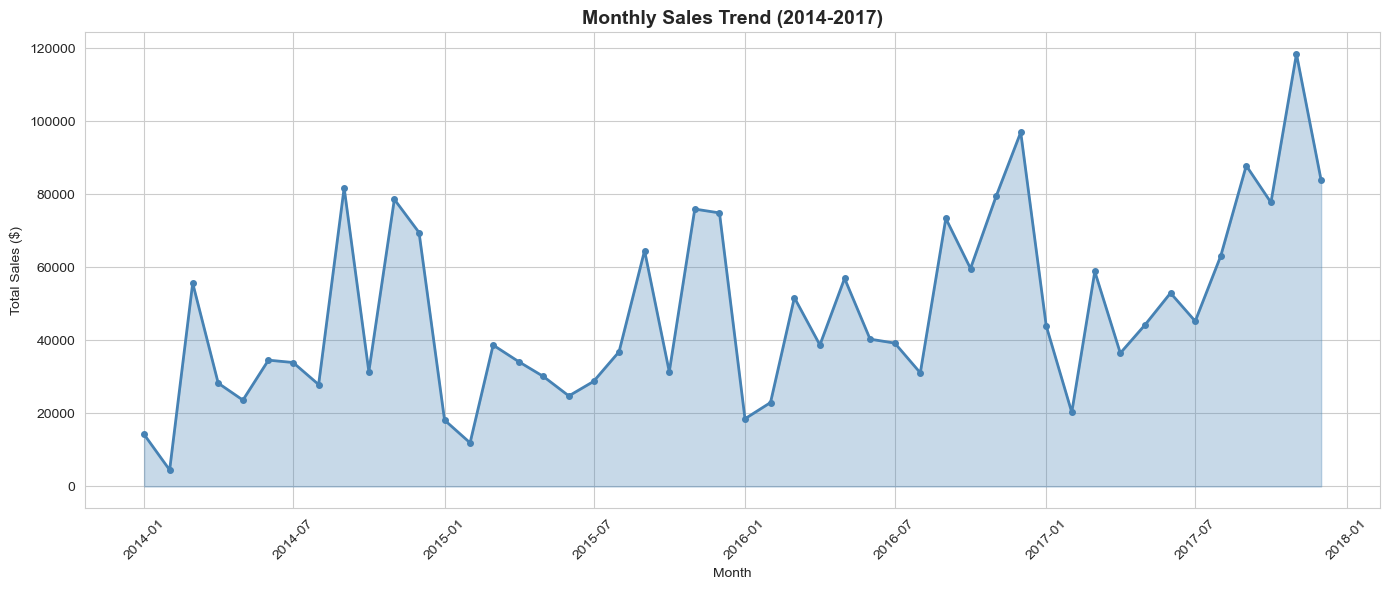

Best Month: November 2017 ($118,447.82)
Worst Month: February 2014 ($4,519.89)


In [5]:
# How does revenue change over time?
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(
    monthly_sales[['Year', 'Month']].assign(Day=1)
)
monthly_sales = monthly_sales.sort_values('Date')

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'],
         color='steelblue', linewidth=2, marker='o', markersize=4)
plt.fill_between(monthly_sales['Date'], monthly_sales['Sales'],
                 alpha=0.3, color='steelblue')
plt.title('Monthly Sales Trend (2014-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

# Find best and worst months
best_month = monthly_sales.loc[monthly_sales['Sales'].idxmax()]
worst_month = monthly_sales.loc[monthly_sales['Sales'].idxmin()]
print(f"Best Month: {best_month['Date'].strftime('%B %Y')} (${best_month['Sales']:,.2f})")
print(f"Worst Month: {worst_month['Date'].strftime('%B %Y')} (${worst_month['Sales']:,.2f})")

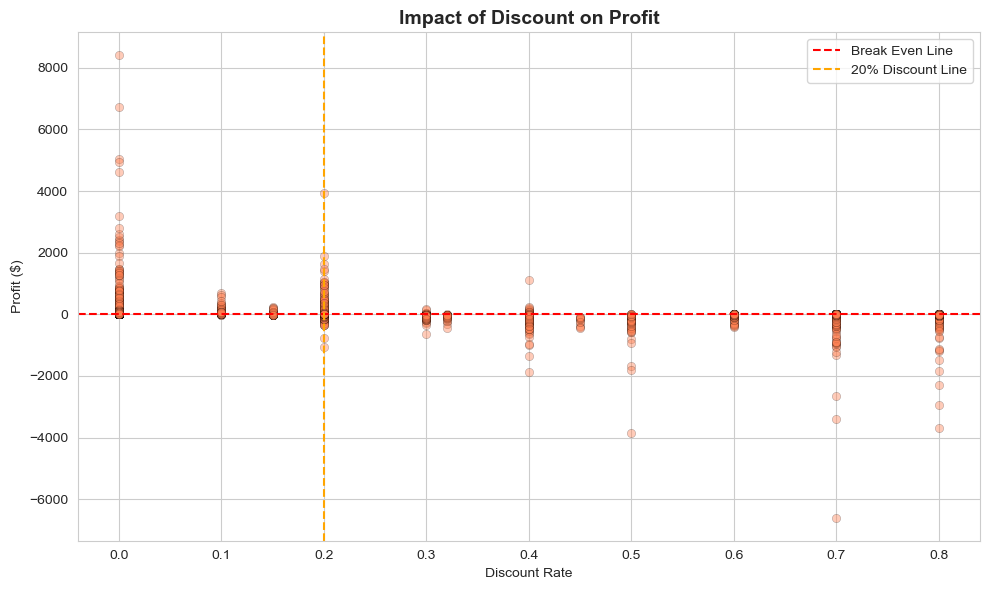

Average Profit with discount > 20%: $-97.18
Average Profit with discount <= 20%: $49.04

Conclusion: High discounts reduce profit by $146.22 per order on average


In [6]:
# KEY BUSINESS INSIGHT — Does discount hurt profit?
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'],
            alpha=0.4, color='coral', edgecolor='black', linewidth=0.3)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Break Even Line')
plt.axvline(x=0.2, color='orange', linestyle='--', linewidth=1.5, label='20% Discount Line')
plt.title('Impact of Discount on Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('discount_impact.png', dpi=150)
plt.show()

# Quantify the impact
high_discount = df[df['Discount'] > 0.2]['Profit'].mean()
low_discount = df[df['Discount'] <= 0.2]['Profit'].mean()
print(f"Average Profit with discount > 20%: ${high_discount:.2f}")
print(f"Average Profit with discount <= 20%: ${low_discount:.2f}")
print(f"\nConclusion: High discounts reduce profit by ${abs(high_discount - low_discount):.2f} per order on average")

Segment Analysis:
       Segment  Total_Sales  Total_Profit  Order_Count  Avg_Order_Value
0     Consumer   1161401.34     134119.21         2586           449.11
1    Corporate    706146.37      91979.13         1514           466.41
2  Home Office    429653.15      60298.68          909           472.67


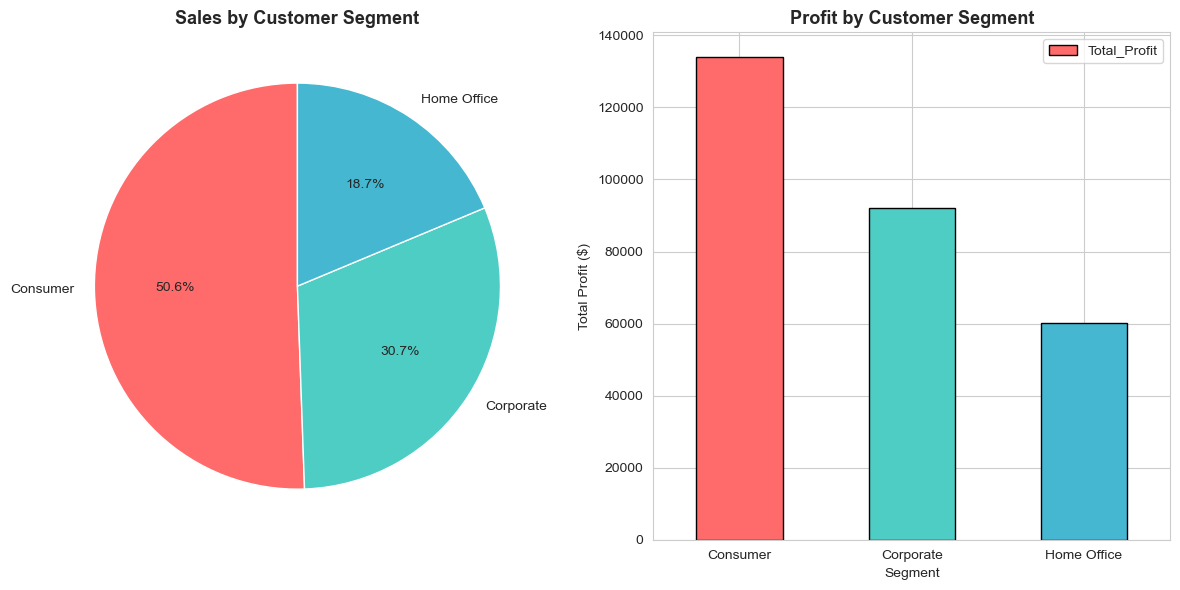

In [7]:
# Which customer segment is most valuable?
segment_stats = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique')
).reset_index()

segment_stats['Avg_Order_Value'] = (
    segment_stats['Total_Sales'] / segment_stats['Order_Count']
)

print("Segment Analysis:")
print(segment_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Sales by Segment
axes[0].pie(segment_stats['Total_Sales'],
            labels=segment_stats['Segment'],
            autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4', '#45B7D1'],
            startangle=90)
axes[0].set_title('Sales by Customer Segment', fontsize=13, fontweight='bold')

# Profit by Segment
segment_stats.plot(x='Segment', y='Total_Profit', kind='bar',
                   ax=axes[1], color=['#FF6B6B','#4ECDC4','#45B7D1'],
                   edgecolor='black')
axes[1].set_title('Profit by Customer Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=150)
plt.show()

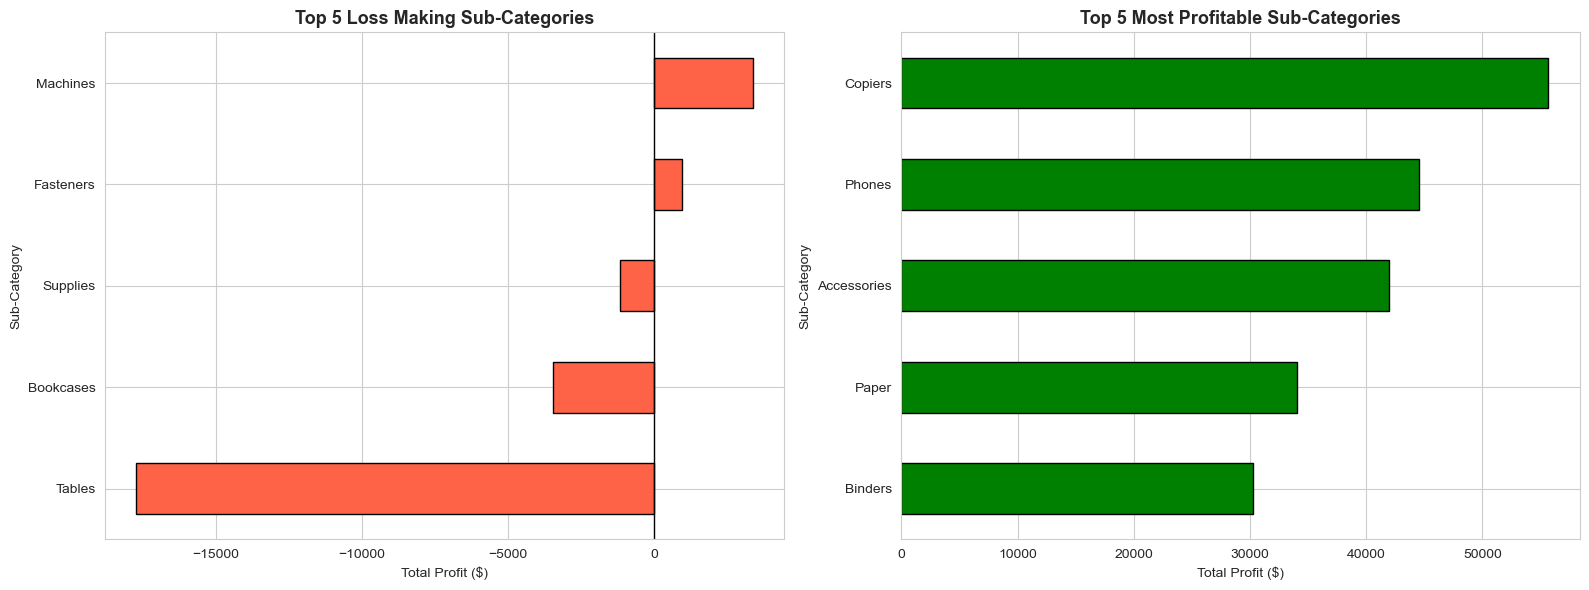

Loss Making Sub-Categories:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64

Most Profitable Sub-Categories:
Sub-Category
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


In [8]:
# Which sub-categories make/lose the most money?
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bottom 5 — Loss makers
subcategory_profit.head(5).plot(kind='barh', ax=axes[0],
                                 color='tomato', edgecolor='black')
axes[0].set_title('Top 5 Loss Making Sub-Categories', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
axes[0].axvline(x=0, color='black', linewidth=1)

# Top 5 — Profit makers
subcategory_profit.tail(5).plot(kind='barh', ax=axes[1],
                                  color='green', edgecolor='black')
axes[1].set_title('Top 5 Most Profitable Sub-Categories', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('subcategory_profit.png', dpi=150)
plt.show()

print("Loss Making Sub-Categories:")
print(subcategory_profit.head(5))
print("\nMost Profitable Sub-Categories:")
print(subcategory_profit.tail(5))

In [9]:
print("=" * 60)
print("KEY BUSINESS INSIGHTS — SUPERSTORE SALES ANALYSIS")
print("=" * 60)

# Insight 1
top_region = df.groupby('Region')['Sales'].sum().idxmax()
top_region_sales = df.groupby('Region')['Sales'].sum().max()
print(f"\n1. {top_region} region leads in sales with ${top_region_sales:,.0f} total revenue")

# Insight 2
top_category = category_stats.loc[category_stats['Total_Profit'].idxmax(), 'Category']
top_margin = category_stats.loc[category_stats['Total_Profit'].idxmax(), 'Profit_Margin_%']
print(f"\n2. {top_category} has the highest profit margin at {top_margin:.1f}%")

# Insight 3
worst_category = category_stats.loc[category_stats['Profit_Margin_%'].idxmin(), 'Category']
worst_margin = category_stats.loc[category_stats['Profit_Margin_%'].idxmin(), 'Profit_Margin_%']
print(f"\n3. {worst_category} has the lowest profit margin at {worst_margin:.1f}%")

# Insight 4
print(f"\n4. Orders with discount > 20% generate average profit of ${high_discount:.2f}")
print(f"   Orders with discount <= 20% generate average profit of ${low_discount:.2f}")
print(f"   High discounts destroy {abs(round((high_discount/low_discount)*100 - 100, 1))}% of profit per order")

# Insight 5
top_segment = segment_stats.loc[segment_stats['Total_Sales'].idxmax(), 'Segment']
top_segment_pct = round(segment_stats.loc[
    segment_stats['Total_Sales'].idxmax(), 'Total_Sales'] / df['Sales'].sum() * 100, 1)
print(f"\n5. {top_segment} segment drives {top_segment_pct}% of total revenue")

# Insight 6
worst_subcat = subcategory_profit.index[0]
worst_subcat_loss = subcategory_profit.values[0]
print(f"\n6. {worst_subcat} is the biggest loss maker with ${worst_subcat_loss:,.0f} total loss")

print("\n" + "=" * 60)

KEY BUSINESS INSIGHTS — SUPERSTORE SALES ANALYSIS

1. West region leads in sales with $725,458 total revenue

2. Technology has the highest profit margin at 17.4%

3. Furniture has the lowest profit margin at 2.5%

4. Orders with discount > 20% generate average profit of $-97.18
   Orders with discount <= 20% generate average profit of $49.04
   High discounts destroy 298.2% of profit per order

5. Consumer segment drives 50.6% of total revenue

6. Tables is the biggest loss maker with $-17,725 total loss

